In [4]:
# Data Handling & Analysis
import pandas as pd                  # For loading, cleaning, and analyzing tabular data
import numpy as np                   # For numerical operations and handling missing values

# Data Visualization
import matplotlib.pyplot as plt      # For creating static plots
import seaborn as sns                # For advanced, beautiful statistical visualizations

# Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re

# Machine Learning / Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans 

# System / Warnings (optional for cleaner output)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("C:/Users/Bagnath/Downloads/Drugs_&_its_effect/drugs_side_effects_drugs_com.csv")

In [5]:
# Data Cleaning
df.drop(['csa', 'drug_link', 'medical_condition_url'], axis=1, inplace=True)

# Fill binary columns
df['pregnancy_category'] = df['pregnancy_category'].fillna(0)
df['alcohol'] = df['alcohol'].fillna(0)

# Fill other categorical columns with 'Unknown'
for col in ['side_effects', 'generic_name', 'drug_classes', 'brand_names', 'related_drugs']:
    df[col] = df[col].fillna('Unknown')

# Fill numeric columns with median
df['rating'] = df['rating'].fillna(df['rating'].median())
df['no_of_reviews'] = df['no_of_reviews'].fillna(df['no_of_reviews'].median())

In [6]:
df.isnull().sum()

drug_name                        0
medical_condition                0
side_effects                     0
generic_name                     0
drug_classes                     0
brand_names                      0
activity                         0
rx_otc                           1
pregnancy_category               0
alcohol                          0
related_drugs                    0
medical_condition_description    0
rating                           0
no_of_reviews                    0
dtype: int64

In [7]:
df

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",Unknown,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,Unknown,Weight Loss (Obesity/Overweight) More than hal...,7.0,12.0
2928,Fendique ER,Weight Loss,Unknown,phendimetrazine tartrate,"Anorexiants, CNS stimulants",Unknown,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.0,12.0
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,Unknown,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.0,12.0


## Drug Similarity Clustering (Side Effects)

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download resources if not done
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    text = str(text).lower()
    words = word_tokenize(text)
    # Filter out punctuation & stopwords
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return list(set(words))  # unique words only

# Apply to text columns
df['tokenized_side_effects'] = df['side_effects'].apply(tokenize_text)
df['tokenized_medical_desc'] = df['medical_condition_description'].apply(tokenize_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bagnath\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bagnath\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# Convert side effects to TF-IDF vectors
df['side_effects_str'] = df['tokenized_side_effects'].apply(lambda x: ' '.join(x))
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['side_effects_str'])

# Compute cosine similarity
similarity_matrix = cosine_similarity(X)

# Dimensionality reduction for visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(similarity_matrix)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(similarity_matrix)

df['side_effect_cluster'] = clusters

In [10]:
df['side_effect_cluster']

0       2
1       2
2       2
3       2
4       0
       ..
2926    2
2927    2
2928    1
2929    0
2930    0
Name: side_effect_cluster, Length: 2931, dtype: int32

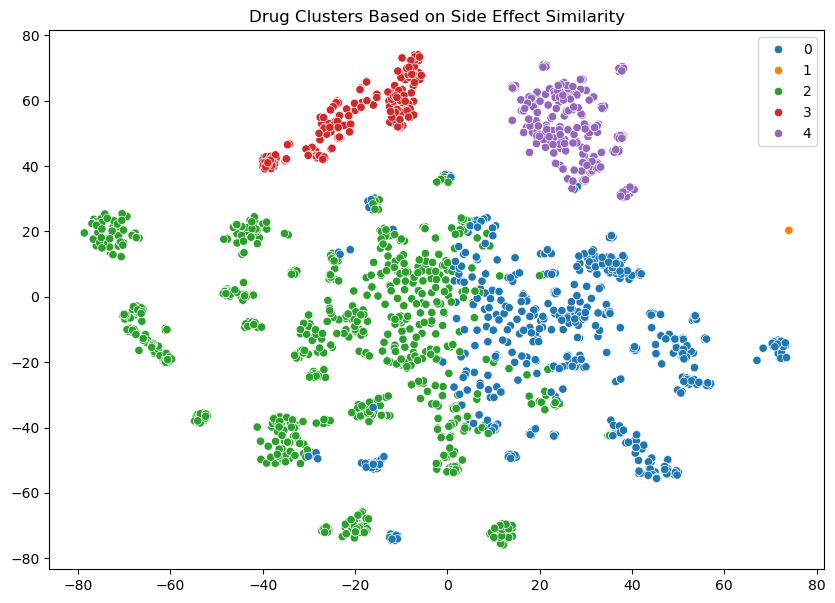

In [11]:
# Plot clusters
plt.figure(figsize=(10,7))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=clusters, palette='tab10')
plt.title("Drug Clusters Based on Side Effect Similarity")
plt.show()

## Related Drugs Network

In [12]:
import networkx as nx

In [13]:
# TEXT CLEANING FUNCTIONS

stopwords_set = set(stopwords.words('english'))

def tokenize_text(text):
    text = str(text)
    words = word_tokenize(text.lower())
    words = [w for w in words if w not in string.punctuation and w not in stopwords_set]
    return list(set(words))  # return unique words

nltk.download('punkt')
nltk.download('punkt_tab')   # <— add this line
nltk.download('stopwords')

# Apply tokenization
df['tokenized_side_effects'] = df['side_effects'].apply(tokenize_text)
df['tokenized_medical_desc'] = df['medical_condition_description'].apply(tokenize_text)

# Related Drugs Extraction (Improved)
def extract_related_drugs(text):
    s = str(text)
    if s.lower() in ('nan', 'none', '', 'unknown'):
        return []
    matches = re.findall(r'([^:\|]+):', s)
    cleaned = [m.strip() for m in matches if m.strip()]
    return cleaned

df['tokenized_related_drugs'] = df['related_drugs'].apply(extract_related_drugs)

print("Preprocessing completed successfully!")
print(df[['tokenized_side_effects', 'tokenized_related_drugs']].head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bagnath\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bagnath\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bagnath\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing completed successfully!
                              tokenized_side_effects  \
0  [little, drug, easy, affect, short, urine, wea...   
1  [little, doctor, throat, nausea, side, increas...   
2  [little, patchy, easy, cough, short, urine, we...   
3  [increased, urine, stuffy, depression, feeling...   
4  [doctor, throat, side, even, peeling, dose, hi...   

                             tokenized_related_drugs  
0  [amoxicillin, https, prednisone, https, albute...  
1  [amlodipine, https, lisinopril, https, losarta...  
2  [amoxicillin, https, prednisone, https, doxycy...  
3  [doxycycline, https, clindamycin topical, http...  
4  [doxycycline, https, metronidazole, https, met...  


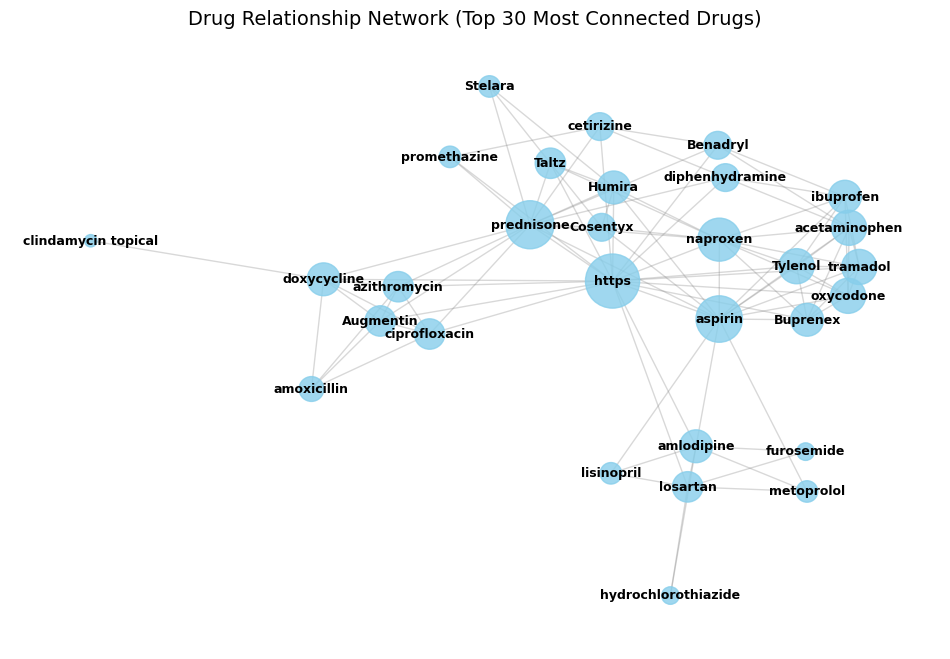

In [15]:
# Build a graph
G = nx.Graph()
for idx, row in df.iterrows():
    drug = row['drug_name']
    related = row['tokenized_related_drugs']
    for r in related:
        G.add_edge(drug, r)

# Compute node degrees
degree_dict = dict(G.degree())
sorted_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

# Select top N most connected drugs
top_n = 30
top_nodes = [n for n, d in sorted_nodes[:top_n]]

# Subgraph of top connected drugs
G_sub = G.subgraph(top_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sub, k=0.5, seed=42)

nx.draw_networkx_nodes(G_sub, pos, 
                       node_size=[v*80 for v in dict(G_sub.degree()).values()],
                       node_color='skyblue', 
                       alpha=0.8)

nx.draw_networkx_edges(G_sub, pos, 
                       alpha=0.3, 
                       edge_color='gray')

nx.draw_networkx_labels(G_sub, pos, 
                        font_size=9, 
                        font_weight='bold')

plt.title(f"Drug Relationship Network (Top {top_n} Most Connected Drugs)", fontsize=14)
plt.axis('off')
plt.show()

# Subgraph of top connected drugs
G_sub = G.subgraph(top_nodes)

## Ratings & Activity Analysis

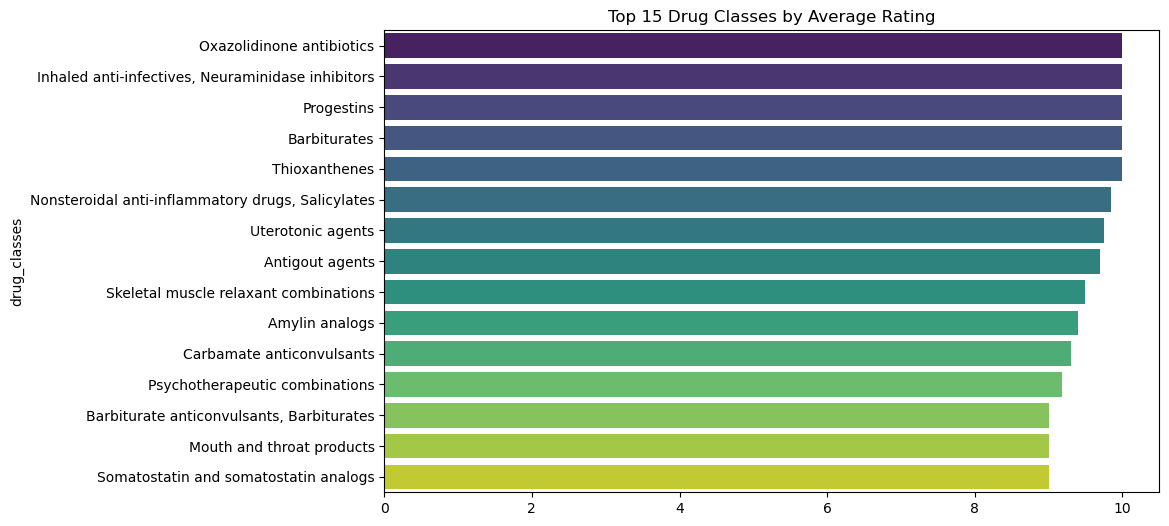

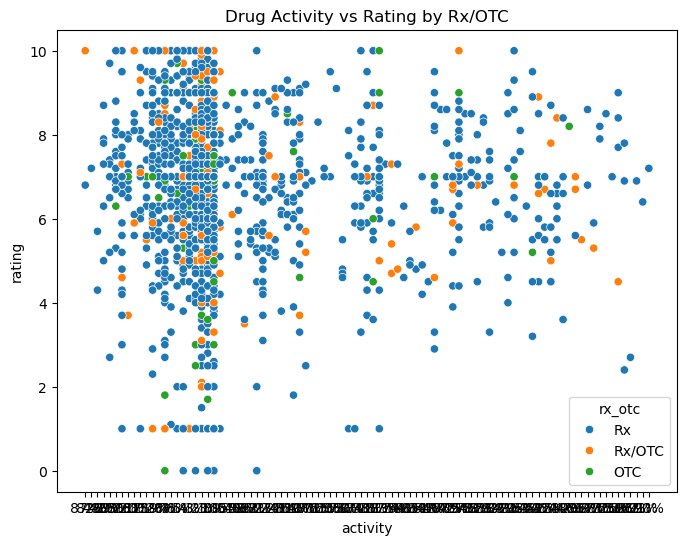

In [16]:
# Rating by drug class
top_classes = df.groupby('drug_classes')['rating'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_classes.values, y=top_classes.index, palette='viridis')
plt.title("Top 15 Drug Classes by Average Rating")
plt.show()

# Activity vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='activity', y='rating', hue='rx_otc')
plt.title("Drug Activity vs Rating by Rx/OTC")
plt.show()

## Condition-Specific Side Effect Analysis

In [17]:
# Unique side effects per condition
condition_side_effects = (
    df.groupby('medical_condition')['tokenized_side_effects']
    .apply(lambda x: set([item for sublist in x for item in sublist]))
)

# Count of unique side effects per condition
condition_side_effects_count = condition_side_effects.apply(len).sort_values(ascending=False)

condition_side_effects_count.head(10)

medical_condition
IBD (Bowel)          1978
Psoriasis            1965
Insomnia             1936
Asthma               1799
Covid 19             1665
Diabetes (Type 1)    1515
Pain                 1147
Hypertension          932
Acne                  922
Osteoarthritis        869
Name: tokenized_side_effects, dtype: int64

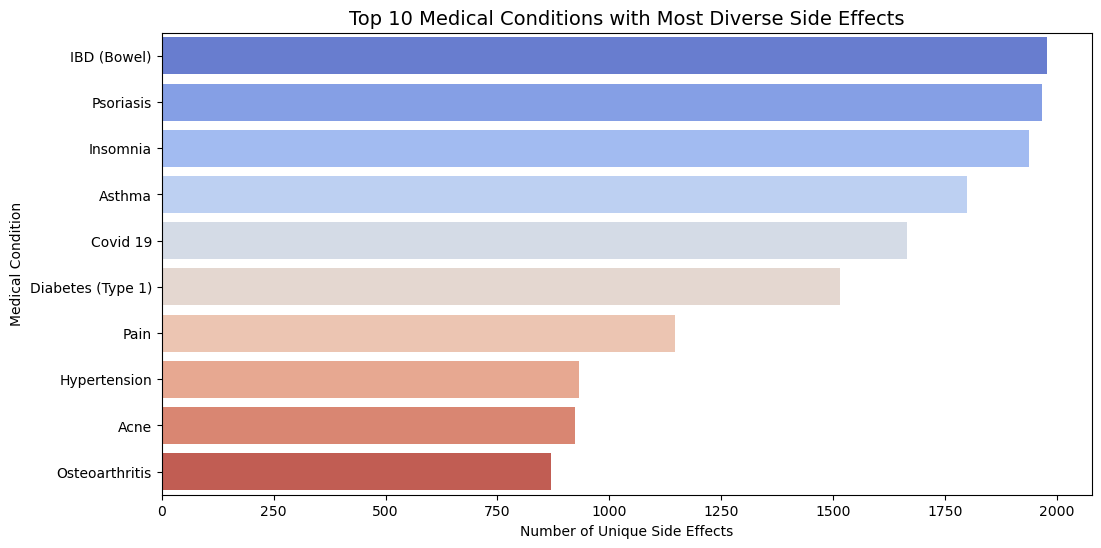

In [20]:
## Visualize Top 10 Conditions with Most Diverse Side Effects

plt.figure(figsize=(12,6))
sns.barplot(
    x=condition_side_effects_count.head(10).values,
    y=condition_side_effects_count.head(10).index,
    palette='coolwarm'
)
plt.title("Top 10 Medical Conditions with Most Diverse Side Effects", fontsize=14)
plt.xlabel("Number of Unique Side Effects")
plt.ylabel("Medical Condition")
plt.show()

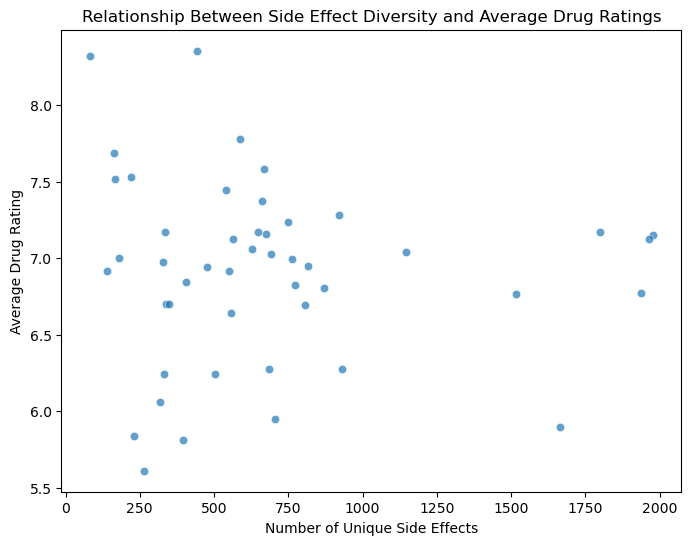

In [21]:
## Compare Average Drug Ratings vs Side Effect Diversity

avg_rating_per_condition = df.groupby('medical_condition')['rating'].mean()
combined_df = pd.DataFrame({
    'unique_side_effects': condition_side_effects_count,
    'avg_rating': avg_rating_per_condition
}).dropna()

plt.figure(figsize=(8,6))
sns.scatterplot(data=combined_df, x='unique_side_effects', y='avg_rating', alpha=0.7)
plt.title("Relationship Between Side Effect Diversity and Average Drug Ratings")
plt.xlabel("Number of Unique Side Effects")
plt.ylabel("Average Drug Rating")
plt.show()

In [22]:
## Identify the Most Common Side Effects per Condition

from collections import Counter

def most_common_side_effects(effect_list):
    flat = [item for sublist in effect_list for item in sublist]
    return [w for w, _ in Counter(flat).most_common(5)]  # top 5

common_effects_per_condition = (
    df.groupby('medical_condition')['tokenized_side_effects']
    .apply(most_common_side_effects)
)

common_effects_per_condition.head(10)

medical_condition
ADHD                      [may, side, call, doctor, effects]
AIDS/HIV               [may, side, doctor, effects, feeling]
Acne                    [may, side, effects, skin, swelling]
Allergies              [doctor, side, hives, may, breathing]
Alzheimer's               [doctor, side, may, effects, call]
Angina                 [side, breathing, lips, may, effects]
Anxiety             [side, effects, may, common, drowsiness]
Asthma                 [may, side, effects, breathing, face]
Bipolar Disorder           [may, side, fever, call, effects]
Bronchitis                [side, may, effects, nausea, rash]
Name: tokenized_side_effects, dtype: object

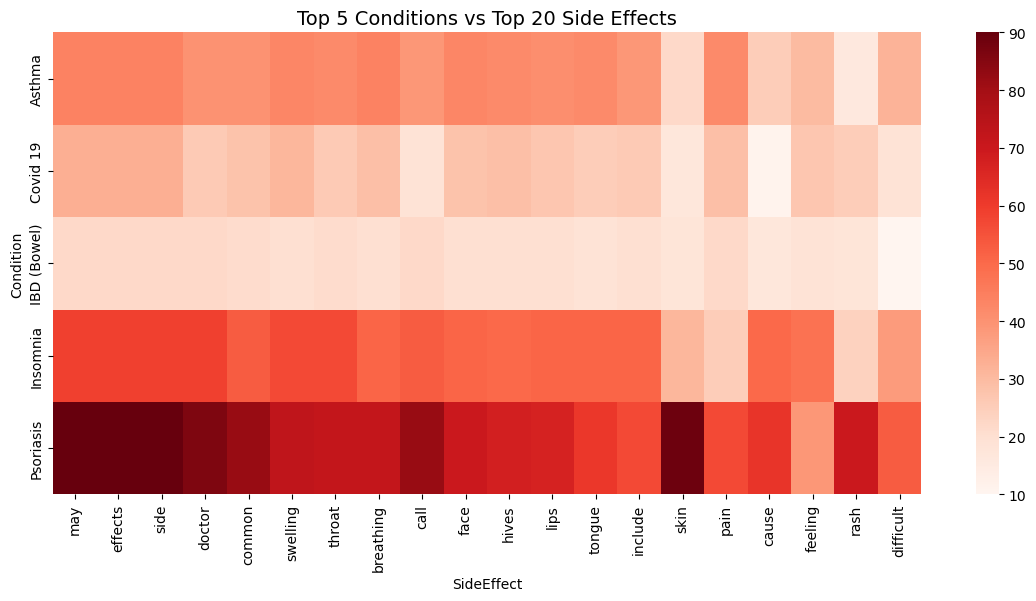

In [23]:
## Optional: Create a Heatmap of Side Effect Frequency Across Top Conditions

top_conditions = condition_side_effects_count.head(5).index
filtered_df = df[df['medical_condition'].isin(top_conditions)]

# Flatten side effects
rows = []
for _, row in filtered_df.iterrows():
    for s in row['tokenized_side_effects']:
        rows.append([row['medical_condition'], s])

heatmap_df = pd.DataFrame(rows, columns=['Condition', 'SideEffect'])
pivot_df = (
    heatmap_df.pivot_table(index='Condition', columns='SideEffect', aggfunc=len, fill_value=0)
)

# Limit to top 20 side effects overall
top_side_effects = pivot_df.sum().sort_values(ascending=False).head(20).index
pivot_df = pivot_df[top_side_effects]

plt.figure(figsize=(14,6))
sns.heatmap(pivot_df, cmap='Reds')
plt.title("Top 5 Conditions vs Top 20 Side Effects", fontsize=14)
plt.show()